# SME Business Distress Prediction in East Africa
## Phase 2 — Model Training & Evaluation (v2 — Leakage-Corrected)

**Student:** Leslie Gideon | **Reg:** SCT213-C002-0062/2022  
**Supervisor:** Mr. Adhola Samuel | **Unit:** BIT 2303 / SDS 2406  

### What changed in v2
Phase 1 v2 removed the three distress-signal features from `ALL_FEATURES_FINAL` and
engineered 9 independent replacements. This notebook retrains all four classifiers on
the corrected 32-feature set. Expected honest performance: **ROC-AUC 0.78–0.90**,
**F1-macro 0.55–0.75** — genuine learning, not circular reconstruction.

**Input:**  `SME_Distress_Africa_v2/data/processed/sme_model_ready_v2.csv`  
**Output:** `SME_Distress_Africa_v2/` models, figures, and metadata


## 1. Drive Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/'
DATA_PROC   = PROJECT_DIR + 'data/processed/'
FIGURES_DIR = PROJECT_DIR + 'figures/'
MODELS_DIR  = PROJECT_DIR + 'models/'

for d in [FIGURES_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted. Paths ready.')
print(f'  Data:    {DATA_PROC}')
print(f'  Figures: {FIGURES_DIR}')
print(f'  Models:  {MODELS_DIR}')


Mounted at /content/drive
Drive mounted. Paths ready.
  Data:    /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/data/processed/
  Figures: /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/figures/
  Models:  /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/models/


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve,
    RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

PALETTE = {
    'stable':    '#2196F3',
    'moderate':  '#FF9800',
    'high_risk': '#F44336',
    'highlight': '#0F7B8C',
    'neutral':   '#64748B',
}

print('Libraries loaded.')
print(f'  XGBoost version: {xgb.__version__}')
print(f'  SHAP version:    {shap.__version__}')


Libraries loaded.
  XGBoost version: 3.2.0
  SHAP version:    0.52.0


## 3. Load Data

In [3]:
# Load Phase 1 v2 metadata
with open(DATA_PROC + 'phase1_metadata_v2.json') as f:
    meta = json.load(f)

ALL_FEATURES_FINAL   = meta['ALL_FEATURES_FINAL']
TARGET_MULTI         = meta['TARGET_MULTI']          # 'distress_level'
TARGET_BINARY        = meta['TARGET_BINARY']          # 'at_risk'
LEAKAGE_EXCLUDED     = meta['LEAKAGE_FEATURES_EXCLUDED']

# Load model-ready dataset
df = pd.read_csv(DATA_PROC + 'sme_model_ready_v2.csv')

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Features for model: {len(ALL_FEATURES_FINAL)}')
print(f'Leakage features confirmed excluded: {LEAKAGE_EXCLUDED}')
print()

# Verify no leakage features are present in ALL_FEATURES_FINAL
leaked = [f for f in ALL_FEATURES_FINAL if f in LEAKAGE_EXCLUDED]
if leaked:
    raise ValueError(f'LEAKAGE DETECTED in loaded metadata: {leaked}')
print('✓ Leakage check passed.')

# Class distribution
print('\n3-class distribution:')
label_map = {0: 'Stable', 1: 'Moderate Risk', 2: 'High Risk'}
for v, cnt in df[TARGET_MULTI].value_counts().sort_index().items():
    print(f'  {label_map[v]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')


Loaded: 14,688 rows × 42 cols
Features for model: 32
Leakage features confirmed excluded: ['credit_constrained', 'employment_growth_rate', 'emp_growth_available', 'capacity_util_pct', 'low_capacity', 'very_low_capacity', 'severe_credit_constraint', 'distress_signal_count']

✓ Leakage check passed.

3-class distribution:
  Stable: 6,472 (44.1%)
  Moderate Risk: 6,886 (46.9%)
  High Risk: 1,330 (9.1%)


## 4. Train / Test Split

In [4]:
X = df[ALL_FEATURES_FINAL].copy()
y = df[TARGET_MULTI].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'\nTrain class distribution:')
for v, cnt in y_train.value_counts().sort_index().items():
    print(f'  {label_map[v]}: {cnt:,} ({cnt/len(y_train)*100:.1f}%)')
print(f'\nTest class distribution:')
for v, cnt in y_test.value_counts().sort_index().items():
    print(f'  {label_map[v]}: {cnt:,} ({cnt/len(y_test)*100:.1f}%)')


Train: 11,750 rows  |  Test: 2,938 rows

Train class distribution:
  Stable: 5,177 (44.1%)
  Moderate Risk: 5,509 (46.9%)
  High Risk: 1,064 (9.1%)

Test class distribution:
  Stable: 1,295 (44.1%)
  Moderate Risk: 1,377 (46.9%)
  High Risk: 266 (9.1%)


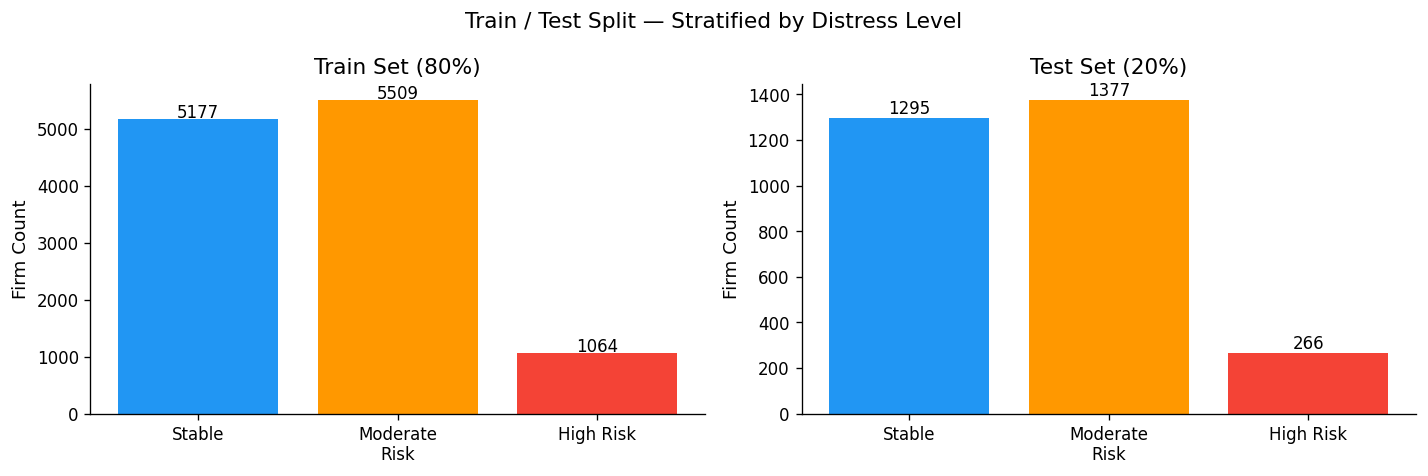

Fig 01 saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = [PALETTE['stable'], PALETTE['moderate'], PALETTE['high_risk']]
names  = ['Stable', 'Moderate\nRisk', 'High Risk']

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts().sort_index(), 'Train Set (80%)'),
    (y_test.value_counts().sort_index(),  'Test Set (20%)')
]):
    ax.bar(names, counts.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Firm Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.suptitle('Train / Test Split — Stratified by Distress Level', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig01_split.png', bbox_inches='tight')
plt.show()
print('Fig 01 saved.')


## 5. Scaling & SMOTE (Training Partition Only)

In [6]:
# Scale features — fit on train only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling applied (fit on train only).')
print(f'  Train shape: {X_train_scaled.shape}')

# SMOTE — oversample minority classes in training set only
# High Risk (class 2) is only 9.1% — SMOTE will balance it
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'\nAfter SMOTE:')
print(f'  Train shape: {X_train_res.shape}')
for v, cnt in pd.Series(y_train_res).value_counts().sort_index().items():
    print(f'  {label_map[v]}: {cnt:,}')

# Save scaler for Streamlit / web predictor
with open(MODELS_DIR + 'scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('\n✓ Scaler saved.')


Scaling applied (fit on train only).
  Train shape: (11750, 32)

After SMOTE:
  Train shape: (16527, 32)
  Stable: 5,509
  Moderate Risk: 5,509
  High Risk: 5,509

✓ Scaler saved.


## 6. Helper Functions

In [7]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, predict, and return a results dict."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    roc_auc  = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_high  = f1_score(y_te, y_pred, labels=[2], average='macro')
    report   = classification_report(y_te, y_pred,
                                     target_names=['Stable','Moderate Risk','High Risk'])

    print(f'\n{'='*60}')
    print(f' {name}')
    print(f'{'='*60}')
    print(f'  ROC-AUC (macro OvR): {roc_auc:.4f}')
    print(f'  F1-macro:            {f1_macro:.4f}')
    print(f'  F1-High Risk:        {f1_high:.4f}')
    print(f'\n{report}')

    return {
        'name':      name,
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'roc_auc':   roc_auc,
        'f1_macro':  f1_macro,
        'f1_high':   f1_high,
        'report':    report,
    }

print('Helper functions defined.')


Helper functions defined.


## 7. Model Training

In [8]:
# ── Model 1: Logistic Regression (baseline) ──────────────────────────────────
lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    random_state=42
)
res_lr = evaluate_model('Logistic Regression', lr,
                         X_train_res, y_train_res,
                         X_test_scaled, y_test)



 Logistic Regression
  ROC-AUC (macro OvR): 0.8432
  F1-macro:            0.5351
  F1-High Risk:        0.3321

               precision    recall  f1-score   support

       Stable       0.77      0.99      0.86      1295
Moderate Risk       0.84      0.27      0.41      1377
    High Risk       0.22      0.68      0.33       266

     accuracy                           0.62      2938
    macro avg       0.61      0.65      0.54      2938
 weighted avg       0.75      0.62      0.60      2938



In [9]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
res_rf = evaluate_model('Random Forest', rf,
                         X_train_res, y_train_res,
                         X_test_scaled, y_test)



 Random Forest
  ROC-AUC (macro OvR): 0.8591
  F1-macro:            0.6033
  F1-High Risk:        0.3662

               precision    recall  f1-score   support

       Stable       0.77      0.99      0.87      1295
Moderate Risk       0.85      0.44      0.58      1377
    High Risk       0.27      0.58      0.37       266

     accuracy                           0.69      2938
    macro avg       0.63      0.67      0.60      2938
 weighted avg       0.76      0.69      0.69      2938



In [10]:
# ── Model 3: XGBoost (initial) ───────────────────────────────────────────────
# class_weight handled by scale_pos_weight via sample_weight below
n_stable   = (y_train_res == 0).sum()
n_moderate = (y_train_res == 1).sum()
n_high     = (y_train_res == 2).sum()

xgb_init = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
res_xgb = evaluate_model('XGBoost (Initial)', xgb_init,
                          X_train_res, y_train_res,
                          X_test_scaled, y_test)



 XGBoost (Initial)
  ROC-AUC (macro OvR): 0.8636
  F1-macro:            0.6402
  F1-High Risk:        0.2974

               precision    recall  f1-score   support

       Stable       0.79      0.97      0.87      1295
Moderate Risk       0.81      0.71      0.75      1377
    High Risk       0.41      0.23      0.30       266

     accuracy                           0.78      2938
    macro avg       0.67      0.64      0.64      2938
 weighted avg       0.76      0.78      0.76      2938



In [11]:
# ── Model 4: XGBoost Tuned (RandomizedSearchCV) ──────────────────────────────
param_dist = {
    'n_estimators':     [200, 300, 400, 500],
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2, 0.3],
    'reg_alpha':        [0, 0.01, 0.1],
    'reg_lambda':       [1, 1.5, 2],
}

xgb_base = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_macro',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('Running RandomizedSearchCV (50 iterations × 5-fold)...')
search.fit(X_train_res, y_train_res)
print(f'Best params: {search.best_params_}')
print(f'Best CV F1-macro: {search.best_score_:.4f}')

xgb_tuned = search.best_estimator_
res_xgb_tuned = evaluate_model('XGBoost (Tuned)', xgb_tuned,
                                X_train_res, y_train_res,
                                X_test_scaled, y_test)


Running RandomizedSearchCV (50 iterations × 5-fold)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.7}
Best CV F1-macro: 0.8411

 XGBoost (Tuned)
  ROC-AUC (macro OvR): 0.8553
  F1-macro:            0.6201
  F1-High Risk:        0.2350

               precision    recall  f1-score   support

       Stable       0.79      0.96      0.87      1295
Moderate Risk       0.79      0.73      0.76      1377
    High Risk       0.38      0.17      0.23       266

     accuracy                           0.78      2938
    macro avg       0.66      0.62      0.62      2938
 weighted avg       0.76      0.78      0.76      2938



## 8. Evaluation Figures

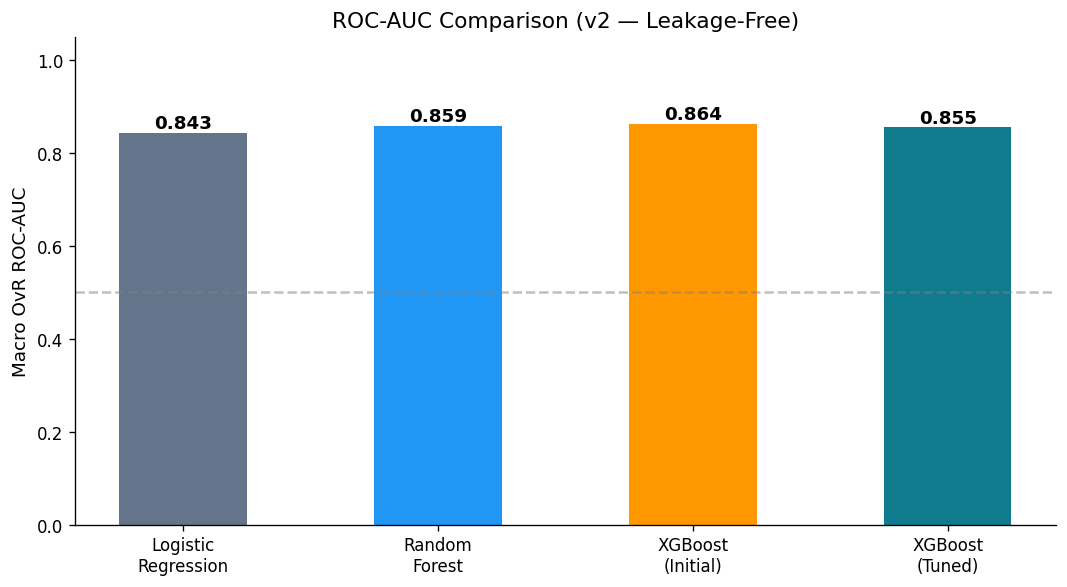

Fig 02 saved.


In [12]:
all_results = [res_lr, res_rf, res_xgb, res_xgb_tuned]

# Fig 02: ROC-AUC comparison
fig, ax = plt.subplots(figsize=(9, 5))
names_short = ['Logistic\nRegression', 'Random\nForest',
               'XGBoost\n(Initial)', 'XGBoost\n(Tuned)']
roc_vals = [r['roc_auc'] for r in all_results]
colors_bar = [PALETTE['neutral'], PALETTE['stable'],
              PALETTE['moderate'], PALETTE['highlight']]
bars = ax.bar(names_short, roc_vals, color=colors_bar, width=0.5)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_title('ROC-AUC Comparison (v2 — Leakage-Free)', fontsize=13)
ax.set_ylabel('Macro OvR ROC-AUC')
for bar, val in zip(bars, roc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig02_roc_comparison.png', bbox_inches='tight')
plt.show()
print('Fig 02 saved.')


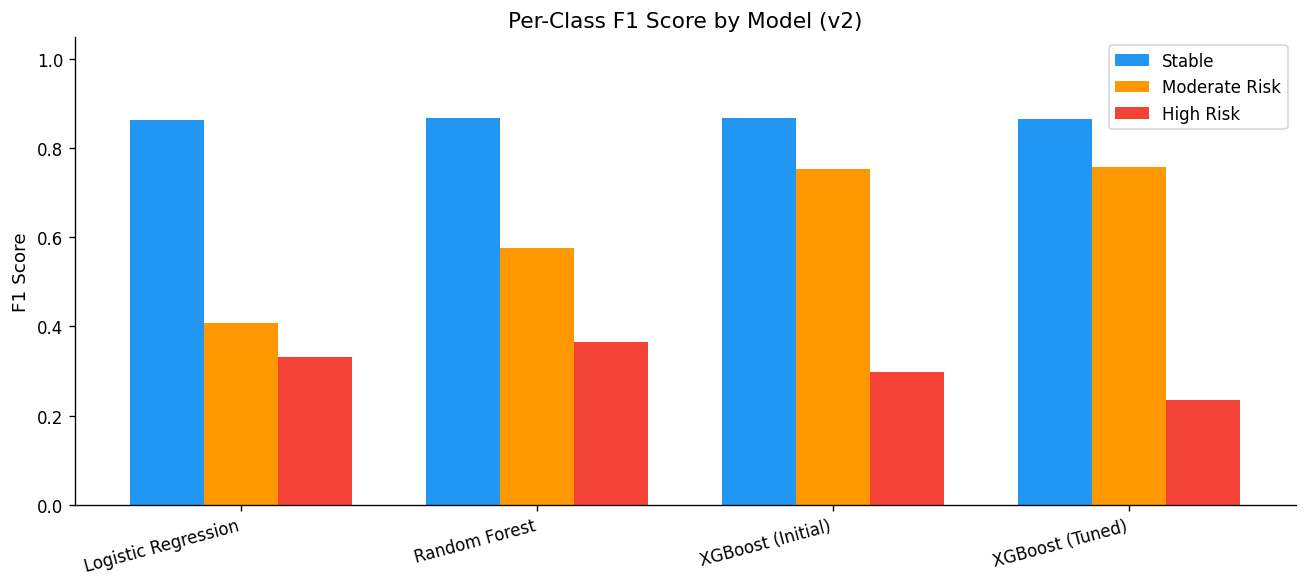

Fig 03 saved.


In [13]:
# Fig 03: Per-class F1 scores
fig, ax = plt.subplots(figsize=(11, 5))

model_names = [r['name'] for r in all_results]
x = np.arange(len(model_names))
width = 0.25

for i, (cls_idx, cls_name, col) in enumerate(
    [(0, 'Stable', PALETTE['stable']),
     (1, 'Moderate Risk', PALETTE['moderate']),
     (2, 'High Risk', PALETTE['high_risk'])]
):
    f1_vals = [f1_score(y_test, r['y_pred'], labels=[cls_idx], average='macro')
               for r in all_results]
    ax.bar(x + (i - 1) * width, f1_vals, width, label=cls_name, color=col)

ax.set_xticks(x)
ax.set_xticklabels([r['name'] for r in all_results], rotation=15, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Model (v2)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig03_perclass_f1.png', bbox_inches='tight')
plt.show()
print('Fig 03 saved.')


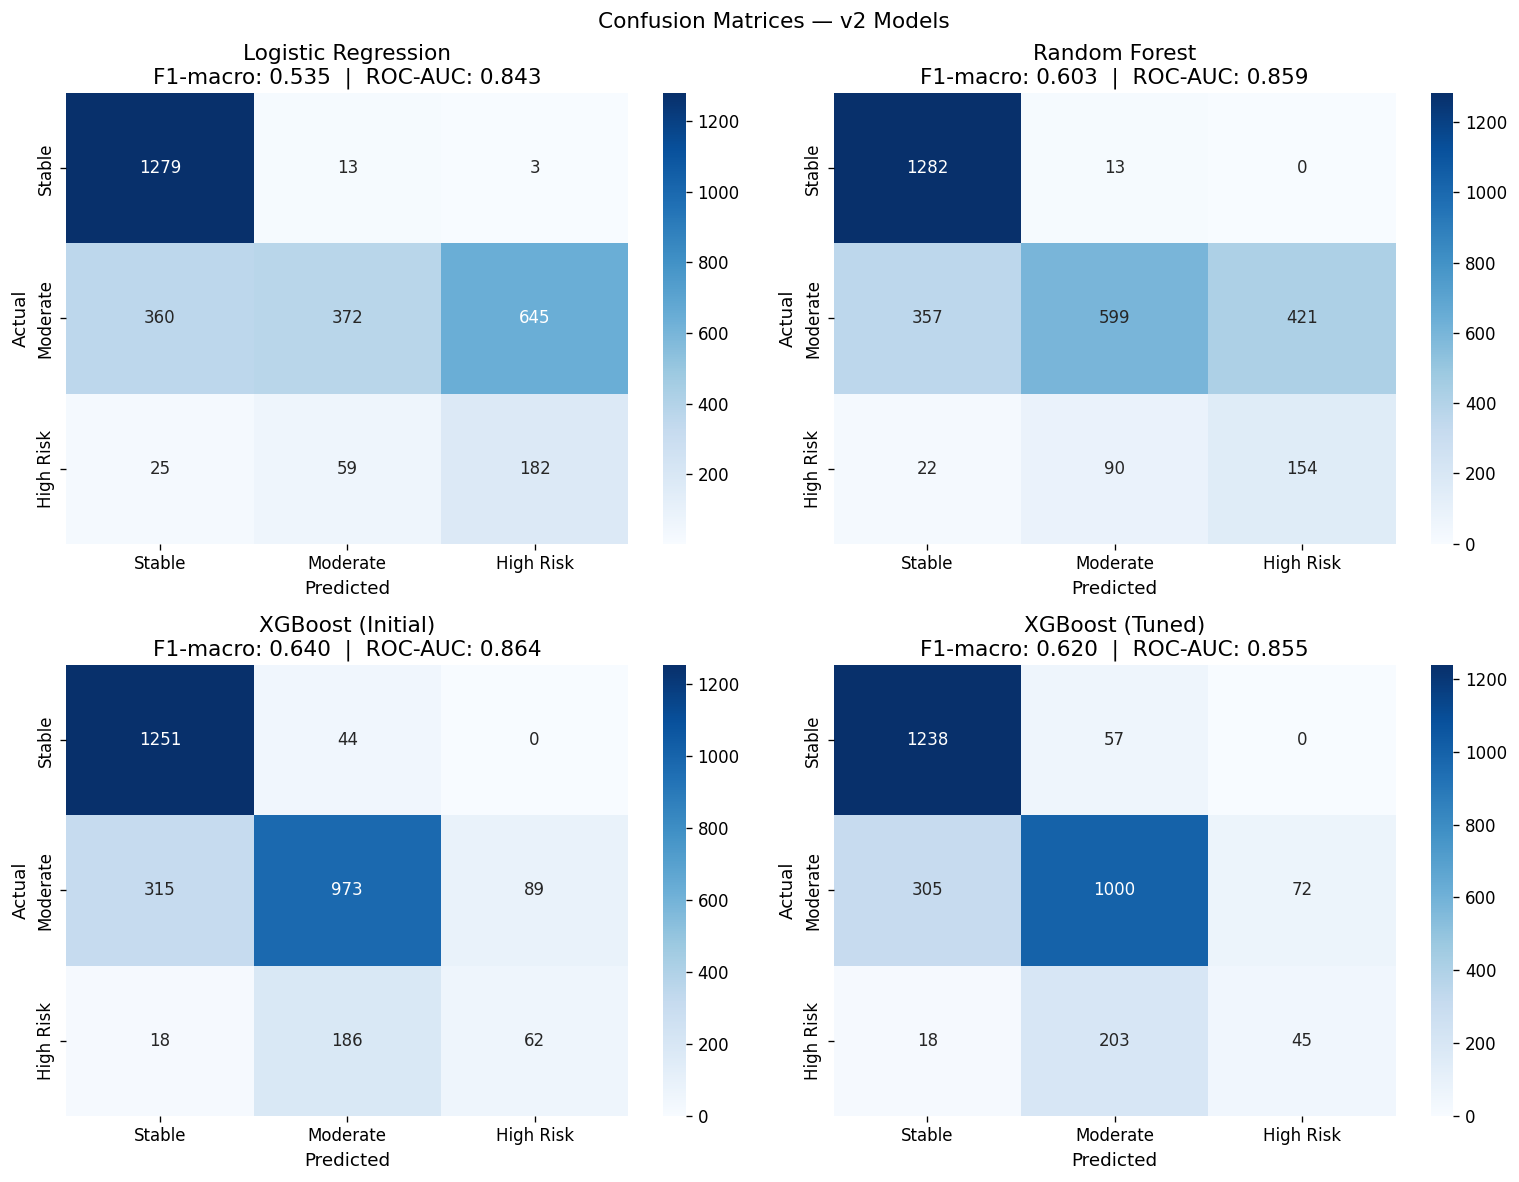

Fig 04 saved.


In [14]:
# Fig 04: Confusion matrices (all 4 models)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, res in zip(axes.flatten(), all_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=['Stable', 'Moderate', 'High Risk'],
                yticklabels=['Stable', 'Moderate', 'High Risk'],
                cmap='Blues')
    ax.set_title(f'{res["name"]}\nF1-macro: {res["f1_macro"]:.3f}  |  ROC-AUC: {res["roc_auc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — v2 Models', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig04_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Fig 04 saved.')


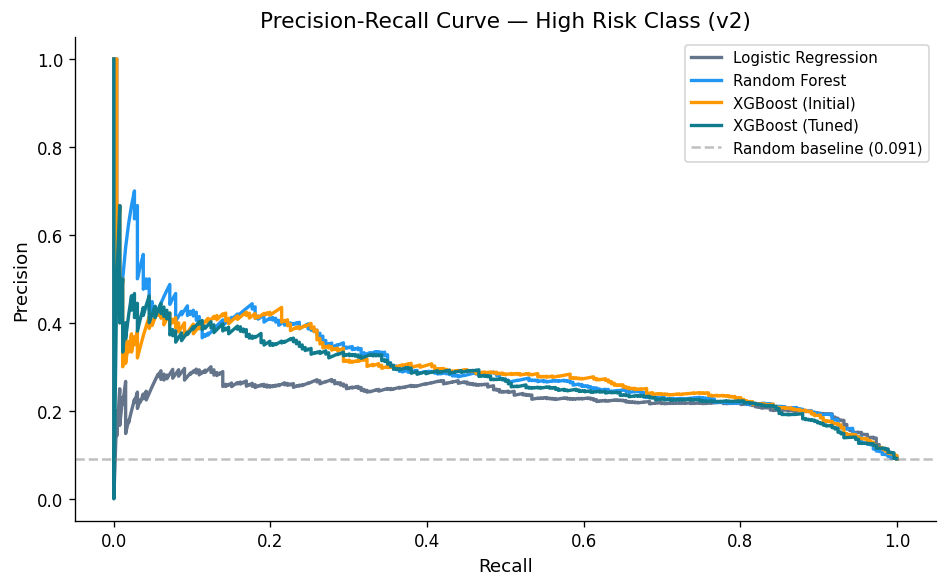

Fig 05 saved.


In [15]:
# Fig 05: Precision-Recall curve for High Risk class (best model)
fig, ax = plt.subplots(figsize=(8, 5))

# Use XGBoost tuned as the main model; plot all for comparison
for res, col in zip(all_results, [PALETTE['neutral'], PALETTE['stable'],
                                   PALETTE['moderate'], PALETTE['highlight']]):
    prec, rec, _ = precision_recall_curve(
        (y_test == 2).astype(int),
        res['y_proba'][:, 2]
    )
    ax.plot(rec, prec, label=res['name'], color=col, linewidth=2)

baseline_high = (y_test == 2).mean()
ax.axhline(baseline_high, color='grey', linestyle='--', alpha=0.5,
           label=f'Random baseline ({baseline_high:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — High Risk Class (v2)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig05_pr_highrisk.png', bbox_inches='tight')
plt.show()
print('Fig 05 saved.')


## 9. SHAP Feature Importance

In [16]:
# Use XGBoost tuned for SHAP — best performing tree model
# Sample 2000 test rows for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_scaled), size=min(2000, len(X_test_scaled)),
                               replace=False)
X_shap = X_test_scaled[sample_idx]

explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_shap)

# shap_values is a list of arrays [class0, class1, class2]
# or a 3D array depending on SHAP version — handle both
if isinstance(shap_values, list):
    shap_arr = np.array(shap_values)   # shape: (3, n_samples, n_features)
else:
    shap_arr = shap_values.transpose(2, 0, 1)  # (3, n_samples, n_features)

mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 1))  # mean over classes & samples
feature_importance = pd.DataFrame({
    'feature':    ALL_FEATURES_FINAL,
    'mean_shap':  mean_abs_shap
}).sort_values('mean_shap', ascending=False)

print('Top 15 features by mean |SHAP|:')
print(feature_importance.head(15).to_string(index=False))


Top 15 features by mean |SHAP|:
                   feature  mean_shap
         needs_finance_bin     1.0036
              has_loan_bin     0.8993
      broad_sector_encoded     0.2396
        sales_per_employee     0.2202
             employees_now     0.1699
   detailed_sector_encoded     0.1376
  biggest_obstacle_encoded     0.1330
            region_encoded     0.1275
                 log_sales     0.1258
      pct_internal_finance     0.0938
               survey_year     0.0631
legal_status_clean_encoded     0.0596
           country_encoded     0.0580
      size_age_interaction     0.0550
        mgmt_quality_score     0.0524


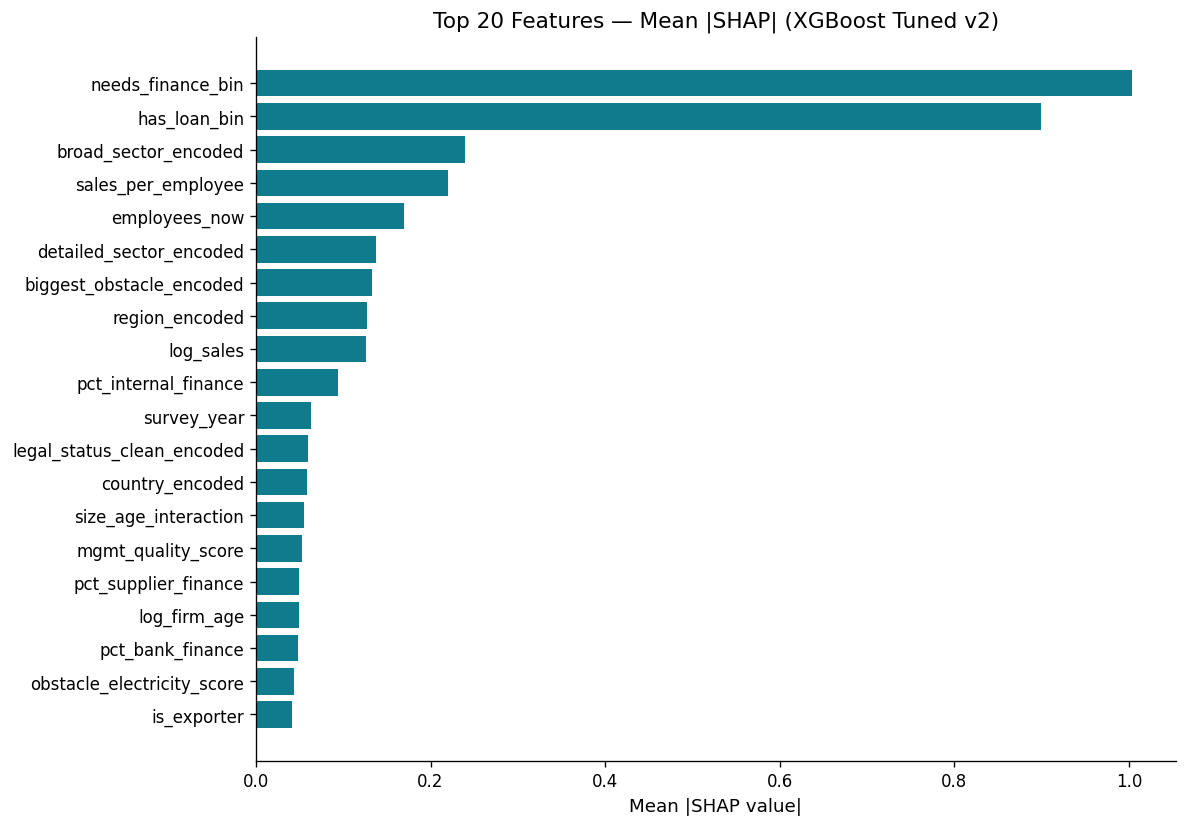

Fig 06 saved.


In [17]:
# Fig 06: Global SHAP importance — top 20
fig, ax = plt.subplots(figsize=(10, 7))
top20 = feature_importance.head(20)
ax.barh(top20['feature'][::-1], top20['mean_shap'][::-1], color=PALETTE['highlight'])
ax.set_title('Top 20 Features — Mean |SHAP| (XGBoost Tuned v2)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig06_shap_global.png', bbox_inches='tight')
plt.show()
print('Fig 06 saved.')


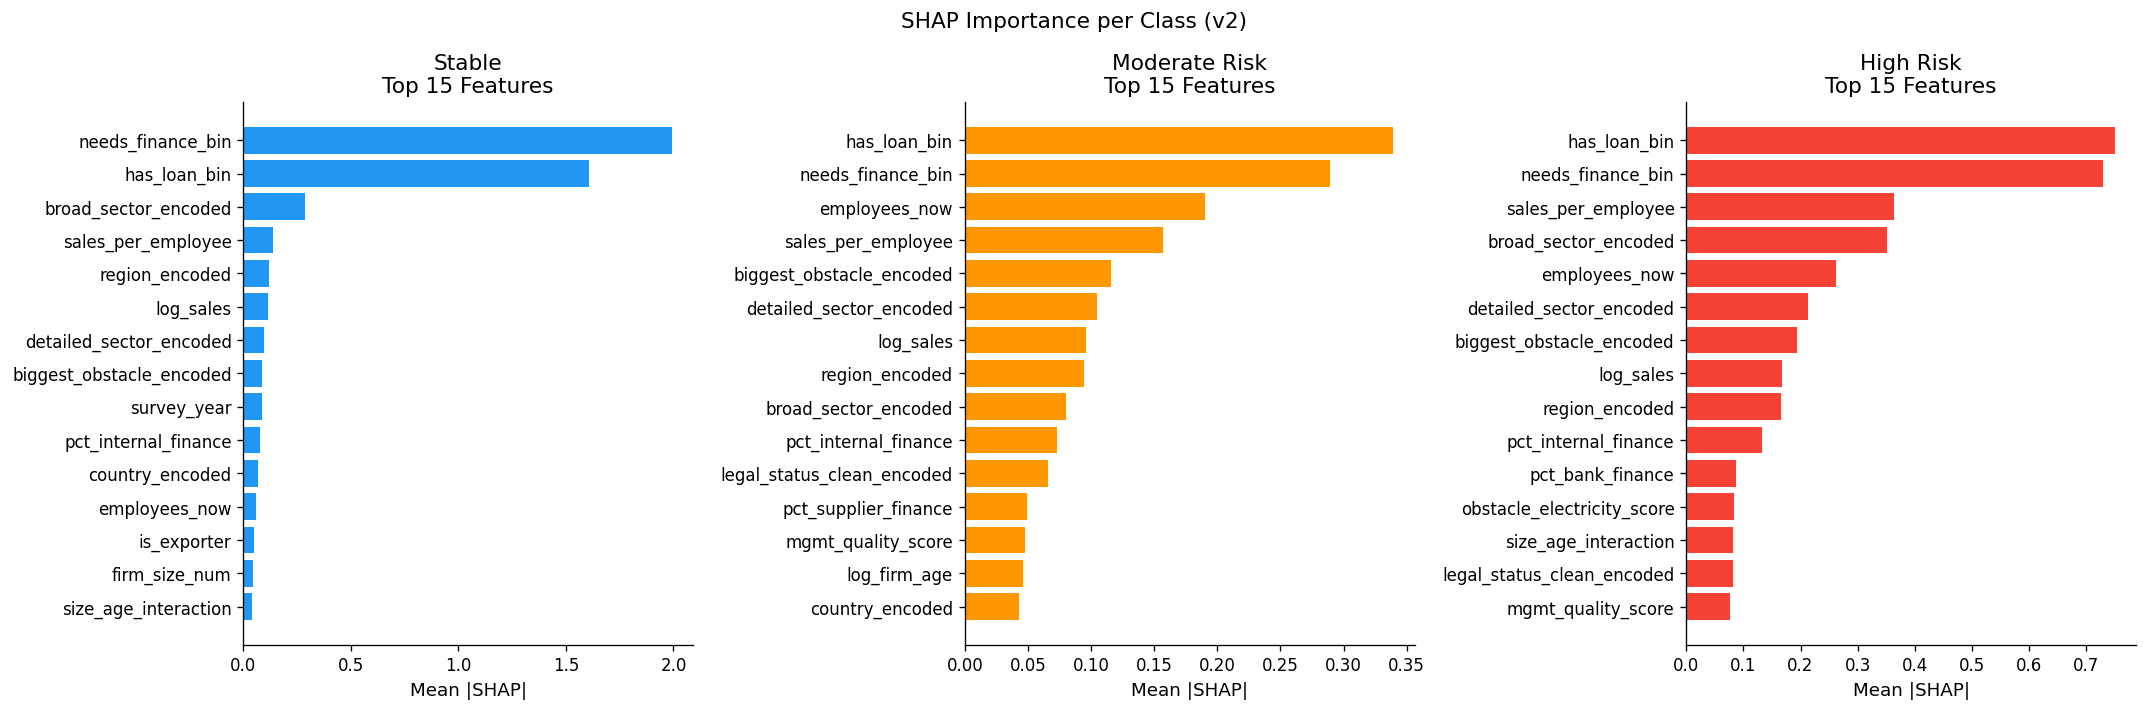

Fig 07 saved.


In [18]:
# Fig 07: SHAP by class — High Risk focus
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_names = ['Stable', 'Moderate Risk', 'High Risk']

for cls_idx, (ax, cls_name) in enumerate(zip(axes, class_names)):
    shap_cls = shap_arr[cls_idx]  # (n_samples, n_features)
    mean_abs = np.abs(shap_cls).mean(axis=0)
    feat_imp_cls = pd.Series(mean_abs, index=ALL_FEATURES_FINAL) \
        .sort_values(ascending=False).head(15)
    color = [PALETTE['stable'], PALETTE['moderate'], PALETTE['high_risk']][cls_idx]
    ax.barh(feat_imp_cls.index[::-1], feat_imp_cls.values[::-1], color=color)
    ax.set_title(f'{cls_name}\nTop 15 Features')
    ax.set_xlabel('Mean |SHAP|')

plt.suptitle('SHAP Importance per Class (v2)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig07_shap_by_class.png', bbox_inches='tight')
plt.show()
print('Fig 07 saved.')


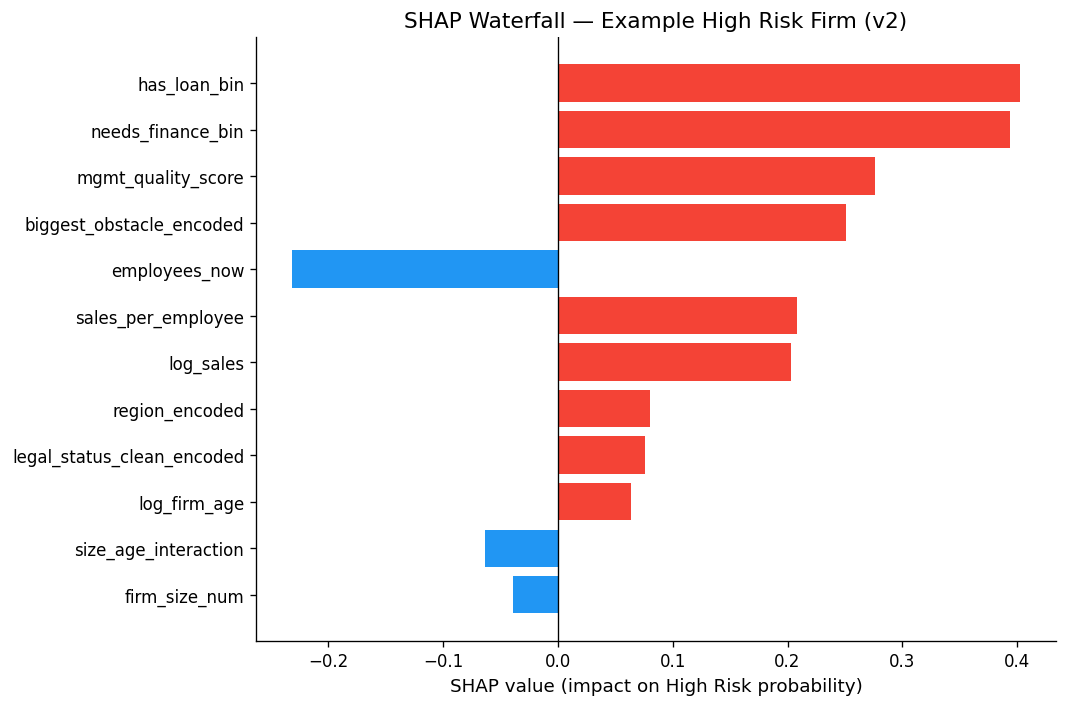

Fig 08 saved.


In [19]:
# Fig 08: SHAP waterfall — single High Risk firm example
high_risk_idx = np.where(y_test.values[sample_idx] == 2)[0]
if len(high_risk_idx) > 0:
    firm_idx = high_risk_idx[0]
    shap_vals_firm = shap_arr[2][firm_idx]  # class 2 = High Risk

    # Build waterfall manually (compatible with all shap versions)
    top_n = 12
    firm_df = pd.DataFrame({
        'feature': ALL_FEATURES_FINAL,
        'shap':    shap_vals_firm
    }).reindex(pd.Series(shap_vals_firm).abs().sort_values(ascending=False).index)
    firm_df = firm_df.head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_wf = [PALETTE['high_risk'] if v > 0 else PALETTE['stable']
                 for v in firm_df['shap']]
    ax.barh(firm_df['feature'][::-1], firm_df['shap'][::-1], color=colors_wf[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('SHAP Waterfall — Example High Risk Firm (v2)')
    ax.set_xlabel('SHAP value (impact on High Risk probability)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'p2_fig08_shap_waterfall.png', bbox_inches='tight')
    plt.show()
    print('Fig 08 saved.')
else:
    print('No High Risk firms in sample — increase sample size if needed.')


## 10. Geographic Sub-Group Evaluation

In [20]:
# Evaluate XGBoost tuned per country
country_col = df.loc[X_test.index, 'country']
results_geo = []

for country in sorted(country_col.unique()):
    mask = (country_col == country).values
    if mask.sum() < 20:
        continue
    y_c    = y_test.values[mask]
    proba_c = res_xgb_tuned['y_proba'][mask]
    pred_c  = res_xgb_tuned['y_pred'][mask]

    try:
        auc = roc_auc_score(y_c, proba_c, multi_class='ovr', average='macro')
    except Exception:
        auc = np.nan

    f1m = f1_score(y_c, pred_c, average='macro', zero_division=0)
    high_risk_rate = (y_c == 2).mean()

    results_geo.append({
        'country': country, 'n': mask.sum(),
        'roc_auc': auc, 'f1_macro': f1m,
        'high_risk_rate': high_risk_rate
    })

geo_df = pd.DataFrame(results_geo).sort_values('roc_auc', ascending=False)
print('Geographic sub-group performance (XGBoost Tuned v2):')
print(geo_df.to_string(index=False))


Geographic sub-group performance (XGBoost Tuned v2):
     country   n  roc_auc  f1_macro  high_risk_rate
    Tanzania 263   0.8912    0.5945          0.0456
      Rwanda 164   0.8831    0.5850          0.0183
South Africa 412   0.8620    0.6973          0.1845
    Ethiopia 396   0.8528    0.5160          0.0505
       Ghana 312   0.8518    0.6520          0.1090
       Kenya 409   0.8233    0.6034          0.1222
      Uganda 236   0.8058    0.5625          0.1314
     Nigeria 746   0.7914    0.4892          0.0536


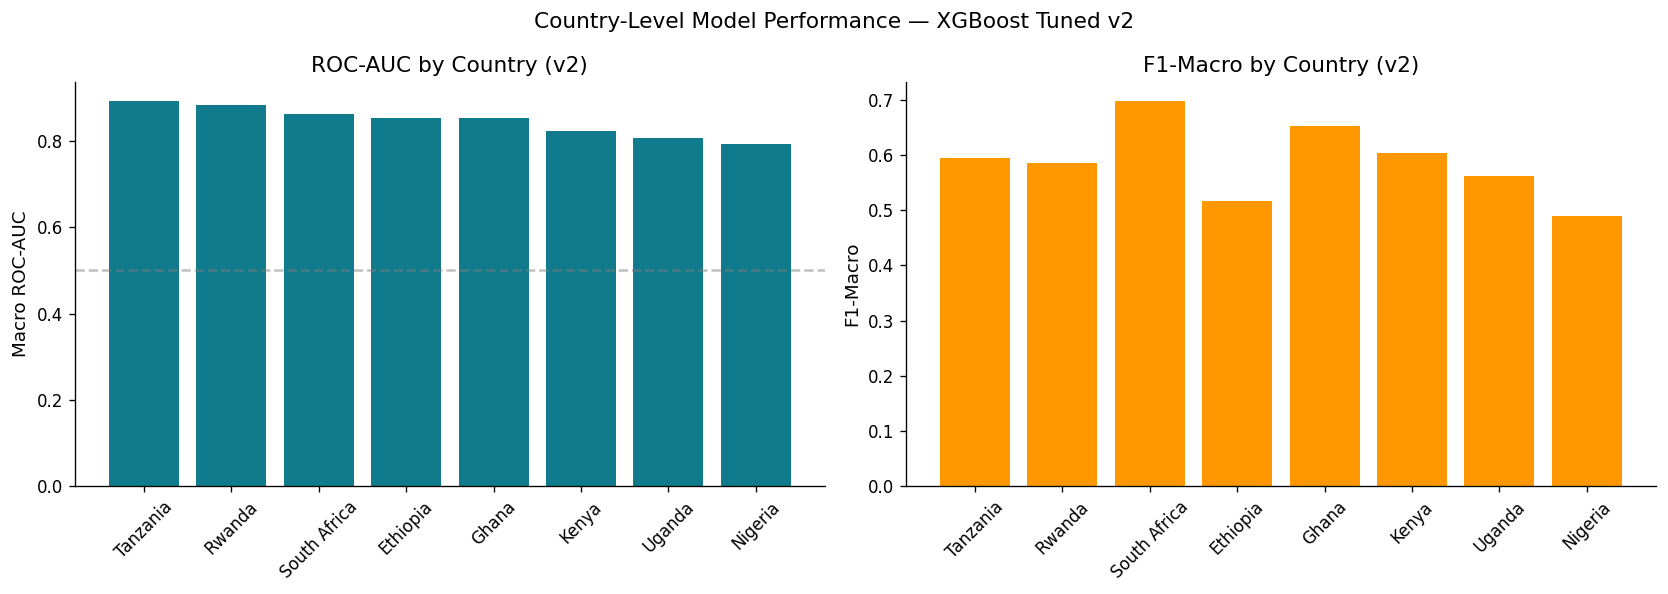

Fig 09 saved.


In [21]:
# Fig 09: Geographic performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(geo_df['country'], geo_df['roc_auc'],
            color=PALETTE['highlight'])
axes[0].set_title('ROC-AUC by Country (v2)')
axes[0].set_ylabel('Macro ROC-AUC')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.5, color='grey', linestyle='--', alpha=0.5)

axes[1].bar(geo_df['country'], geo_df['f1_macro'],
            color=PALETTE['moderate'])
axes[1].set_title('F1-Macro by Country (v2)')
axes[1].set_ylabel('F1-Macro')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Country-Level Model Performance — XGBoost Tuned v2', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig09_geo_performance.png', bbox_inches='tight')
plt.show()
print('Fig 09 saved.')


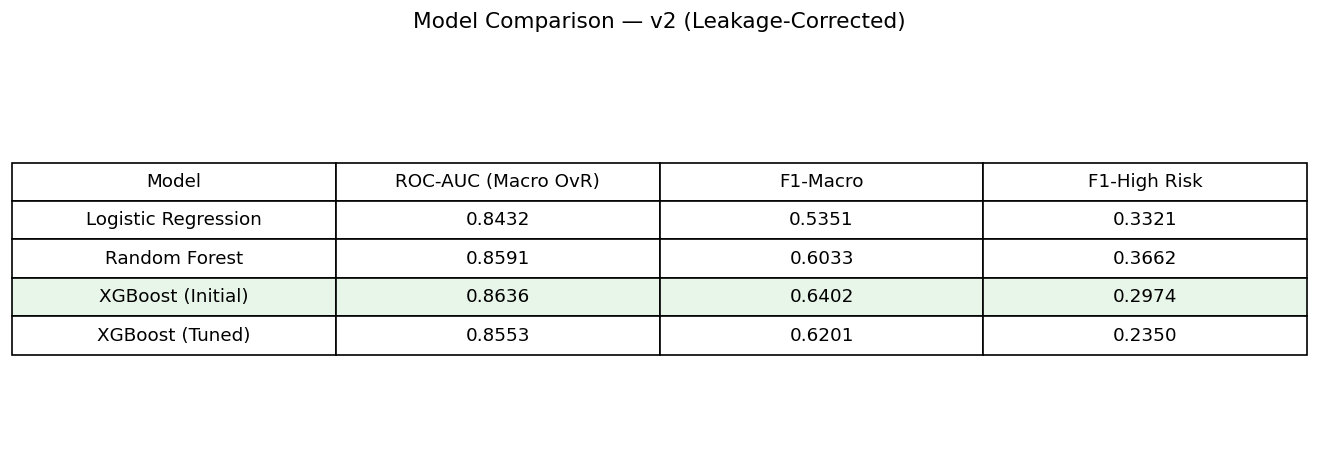

Fig 10 saved.

              Model  ROC-AUC  F1-Macro  F1-High Risk
Logistic Regression   0.8432    0.5351        0.3321
      Random Forest   0.8591    0.6033        0.3662
  XGBoost (Initial)   0.8636    0.6402        0.2974
    XGBoost (Tuned)   0.8553    0.6201        0.2350


In [22]:
# Fig 10: Final model comparison table as figure
summary_data = {
    'Model':       [r['name'] for r in all_results],
    'ROC-AUC':     [r['roc_auc'] for r in all_results],
    'F1-Macro':    [r['f1_macro'] for r in all_results],
    'F1-High Risk':[r['f1_high'] for r in all_results],
}
summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')
tbl = ax.table(
    cellText=[[row['Model'],
               f'{row["ROC-AUC"]:.4f}',
               f'{row["F1-Macro"]:.4f}',
               f'{row["F1-High Risk"]:.4f}']
              for _, row in summary_df.iterrows()],
    colLabels=['Model', 'ROC-AUC (Macro OvR)', 'F1-Macro', 'F1-High Risk'],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)

# Highlight best model row
best_idx = summary_df['ROC-AUC'].idxmax() + 1  # +1 for header row
for col in range(4):
    tbl[best_idx, col].set_facecolor('#E8F5E9')

ax.set_title('Model Comparison — v2 (Leakage-Corrected)', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'p2_fig10_final_comparison.png', bbox_inches='tight')
plt.show()
print('Fig 10 saved.')
print()
print(summary_df.to_string(index=False))


## 11. Save Models & Metadata

In [23]:
# Save all four models
model_files = {
    'model_logistic_regression_v2.pkl': res_lr['model'],
    'model_random_forest_v2.pkl':       res_rf['model'],
    'model_xgboost_v2.pkl':             res_xgb['model'],
    'model_xgboost_tuned_v2.pkl':       res_xgb_tuned['model'],
}

for fname, model in model_files.items():
    with open(MODELS_DIR + fname, 'wb') as f:
        pickle.dump(model, f)
    print(f'✓ Saved: {fname}')

# Save feature names
with open(MODELS_DIR + 'feature_names_v2.pkl', 'wb') as f:
    pickle.dump(ALL_FEATURES_FINAL, f)
print('✓ Saved: feature_names_v2.pkl')


✓ Saved: model_logistic_regression_v2.pkl
✓ Saved: model_random_forest_v2.pkl
✓ Saved: model_xgboost_v2.pkl
✓ Saved: model_xgboost_tuned_v2.pkl
✓ Saved: feature_names_v2.pkl


In [24]:
# Save SHAP feature importance CSV
feature_importance.to_csv(DATA_PROC + 'shap_feature_importance_v2.csv', index=False)
print('✓ Saved: shap_feature_importance_v2.csv')

# Save phase 2 final results CSV
results_rows = []
for r in all_results:
    results_rows.append({
        'model':       r['name'],
        'roc_auc':     r['roc_auc'],
        'f1_macro':    r['f1_macro'],
        'f1_high_risk':r['f1_high'],
    })
results_csv = pd.DataFrame(results_rows)
results_csv.to_csv(DATA_PROC + 'phase2_final_results_v2.csv', index=False)
print('✓ Saved: phase2_final_results_v2.csv')

# Save model comparison summary
results_csv.to_csv(DATA_PROC + 'model_comparison_summary_v2.csv', index=False)
print('✓ Saved: model_comparison_summary_v2.csv')


✓ Saved: shap_feature_importance_v2.csv
✓ Saved: phase2_final_results_v2.csv
✓ Saved: model_comparison_summary_v2.csv


In [26]:
# Save full phase 2 metadata
# First, ensure all numpy types in results_rows and results_geo are converted to native Python types
processed_results_rows = []
for r in all_results:
    processed_results_rows.append({
        'model':       r['name'],
        'roc_auc':     float(r['roc_auc']),     # Convert np.float64 to float
        'f1_macro':    float(r['f1_macro']),    # Convert np.float64 to float
        'f1_high_risk':float(r['f1_high']),     # Convert np.float64 to float
    })

processed_results_geo = []
for item in results_geo:
    processed_results_geo.append({
        'country':        item['country'],
        'n':              int(item['n']),       # Convert np.int64 to int
        'roc_auc':        float(item['roc_auc']), # Convert np.float64 to float
        'f1_macro':       float(item['f1_macro']),# Convert np.float64 to float
        'high_risk_rate': float(item['high_risk_rate']) # Convert np.float64 to float
    })

phase2_meta = {
    'VERSION':              'v2_leakage_corrected',
    'BEST_MODEL':           results_csv.loc[results_csv['roc_auc'].idxmax(), 'model'],
    'BEST_ROC_AUC':         float(results_csv['roc_auc'].max()),
    'BEST_F1_MACRO':        float(results_csv.loc[results_csv['roc_auc'].idxmax(), 'f1_macro']),
    'BEST_F1_HIGH_RISK':    float(results_csv.loc[results_csv['roc_auc'].idxmax(), 'f1_high_risk']),
    'ALL_MODELS':           processed_results_rows, # Use processed list
    'FEATURE_COUNT':        len(ALL_FEATURES_FINAL),
    'TRAIN_SIZE':           len(X_train),
    'TEST_SIZE':            len(X_test),
    'SMOTE_APPLIED':        True,
    'TOP10_SHAP_FEATURES':  feature_importance.head(10)['feature'].tolist(),
    'GEO_RESULTS':          processed_results_geo,  # Use processed list
    'NOTE':                 'Leakage-corrected. Signal features excluded from model inputs.',
}

with open(DATA_PROC + 'phase2_metadata_v2.json', 'w') as f:
    json.dump(phase2_meta, f, indent=2)

print(f'\n✓ Saved: phase2_metadata_v2.json')
print(f'\nBest model: {phase2_meta["BEST_MODEL"]}')
print(f'  ROC-AUC:      {phase2_meta["BEST_ROC_AUC"]:.4f}')
print(f'  F1-Macro:     {phase2_meta["BEST_F1_MACRO"]:.4f}')
print(f'  F1-High Risk: {phase2_meta["BEST_F1_HIGH_RISK"]:.4f}')


✓ Saved: phase2_metadata_v2.json

Best model: XGBoost (Initial)
  ROC-AUC:      0.8636
  F1-Macro:     0.6402
  F1-High Risk: 0.2974


In [27]:
best = phase2_meta

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║        SME DISTRESS — PHASE 2 v2 COMPLETE (LEAKAGE-FREE)           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Best model:     {best['BEST_MODEL']:<38s}  ║
║  ROC-AUC:        {best['BEST_ROC_AUC']:.4f}                                         ║
║  F1-Macro:       {best['BEST_F1_MACRO']:.4f}                                         ║
║  F1-High Risk:   {best['BEST_F1_HIGH_RISK']:.4f}                                         ║
║                                                                      ║
║  Features used:  {best['FEATURE_COUNT']} (leakage signals excluded)                ║
║  SMOTE applied:  Yes (training partition only)                       ║
║                                                                      ║
║  Outputs saved to SME_Distress_Africa_v2/                           ║
║    models/  — 4 pkl files + scaler + feature_names                  ║
║    figures/ — 10 evaluation figures                                  ║
║    data/processed/ — results CSV + metadata JSON                     ║
║                                                                      ║
║  Next step → Update Streamlit app (Phase 3)                         ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║        SME DISTRESS — PHASE 2 v2 COMPLETE (LEAKAGE-FREE)           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Best model:     XGBoost (Initial)                       ║
║  ROC-AUC:        0.8636                                         ║
║  F1-Macro:       0.6402                                         ║
║  F1-High Risk:   0.2974                                         ║
║                                                                      ║
║  Features used:  32 (leakage signals excluded)                ║
║  SMOTE applied:  Yes (training partition only)                       ║
║                                                                      ║
║  Outputs saved to SME_Distress_Africa_v2/                           ║
║    models/  — 4 pkl files + scaler + feature_names                  ║
║    figures/ —